In [ ]:
"""
Note that this code won't work as is because it assumes there is a checkpoint
called hrm_best_34M.pt in a folder checkpoints within HRM_Model
"""
import os
import sys
from pathlib import Path
import torch

torch.manual_seed(8008135)
NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent.parent

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")
from data.Datasets.Sudoku_DataLoader import get_loaders
sys.path.insert(0, os.path.join(CODE_DIR, "code"))
from HRM_Model.HRM_Model import HRM
from HRM_Model.HRM_Components import Encoder, HighLevel, LowLevel, Head
from Utils.checkpointing import load_checkpoint


CODE_DIR: /Users/davidheimowitz/Documents/CS Classes/CS 4782/HRM_Reconstruction
CODE_DIR contents: ['.DS_Store', 'LICENSE', 'requirements.txt', 'Datasets', 'code', 'README.md', 'one_step.md', 'results', '.gitignore', 'Model', '.git', 'data', 'poster']
Device set to mps


/Users/davidheimowitz/.pyenv/versions/3.12.5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Model hyperparameters
d_model = 512
M = 8
N = 4
T = 8
n_layers = 4
n_heads = 8
vocab_size = 10
dropout = 0

# Training hyperparameters
lr = 1e-4
min_lr_ratio = 0.1 # -> 1e-5
lr_warmup = 0.05
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 20 # takes ~ 1 day on my 5080

checkpoint_dir = "checkpoints"

high_level = HighLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

low_level = LowLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

encoder = Encoder(
    vocab_size=vocab_size,
    d_model=d_model,
)

head = Head(
    d_model=d_model,
    vocab_size=vocab_size,
)

HRM_model = HRM(
    L_module=low_level,
    H_module=high_level,
    encoder=encoder,
    head=head,
    M=M,
    N=N,
    T=T,
    max_len=81,
    d_model=d_model,
).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in HRM_model.parameters() if p.requires_grad):,}",
)

HRM_model, _, _, _, _ = load_checkpoint(
    HRM_model,
    optimizer=None,
    scheduler=None,
    path="checkpoints/hrm_best_34M.pt",
    device=device,
)
HRM_model.eval()

Number of trainable parameters: 33,572,864


HRM(
  (low_level): LowLevel(
    (layers): ModuleList(
      (0-3): 4 x PostNormTransformerBlock(
        (attn): MultiHeadSelfAttentionRoPE(
          (q_proj): Linear(in_features=512, out_features=512, bias=False)
          (k_proj): Linear(in_features=512, out_features=512, bias=False)
          (v_proj): Linear(in_features=512, out_features=512, bias=False)
          (o_proj): Linear(in_features=512, out_features=512, bias=False)
          (dropout): Dropout(p=0, inplace=False)
          (rope): RotaryEmbedding()
        )
        (norm1): RMSNorm()
        (ff): SwiGLUFeedForward(
          (w1): Linear(in_features=512, out_features=2048, bias=False)
          (w2): Linear(in_features=512, out_features=2048, bias=False)
          (w3): Linear(in_features=2048, out_features=512, bias=False)
        )
        (norm2): RMSNorm()
        (dropout): Dropout(p=0, inplace=False)
      )
    )
  )
  (high_level): HighLevel(
    (layers): ModuleList(
      (0-3): 4 x PostNormTransformerBl

In [3]:
train_size = 2**18
test_size = 2**15
batch_size = 2**7

train_dataloader, val_dataloader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

Map: 100%|██████████| 32768/32768 [00:02<00:00, 14976.86 examples/s]


In [4]:
data_iter = iter(train_dataloader)


Number of trainable parameters: 33,572,864


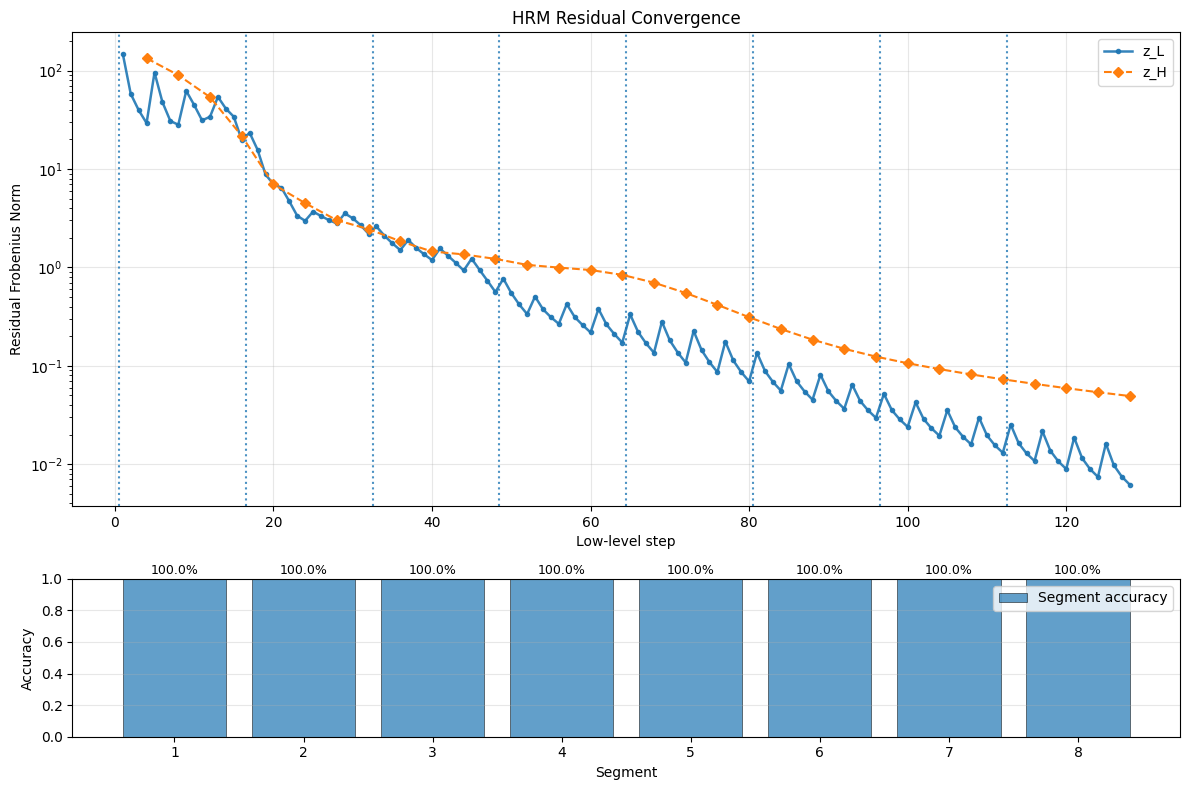

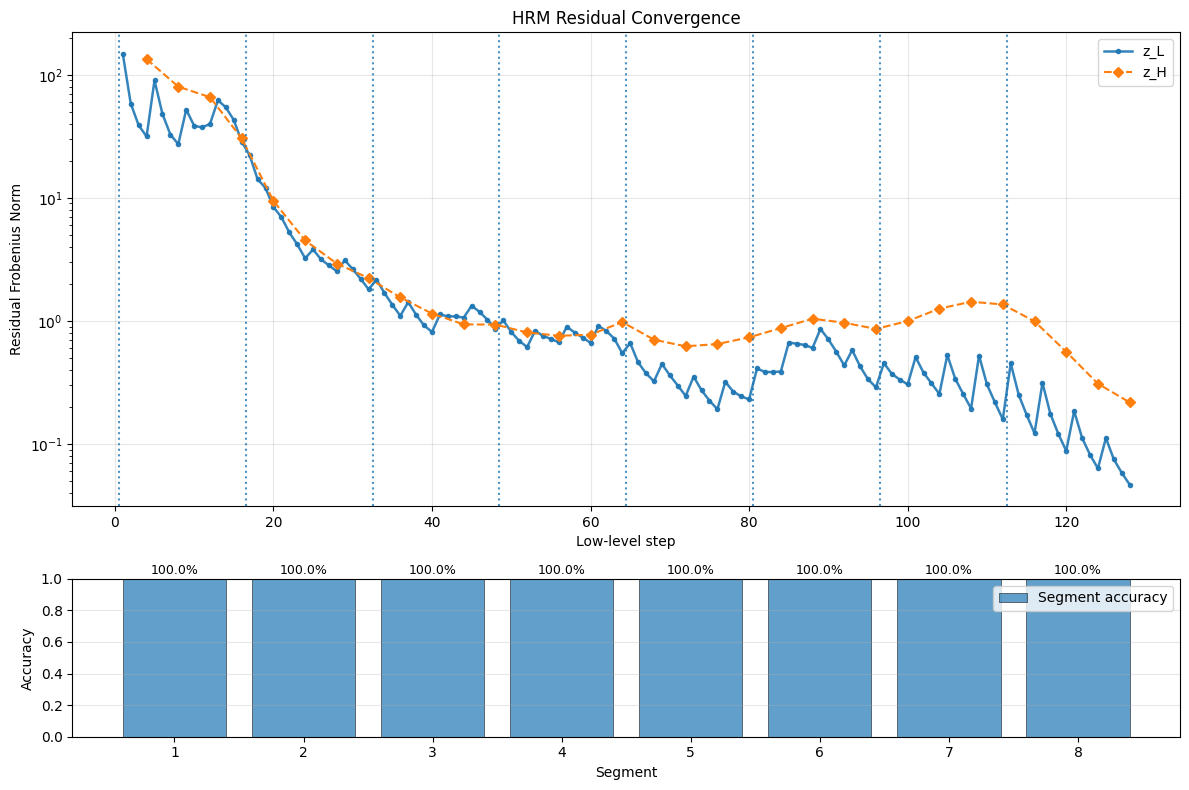

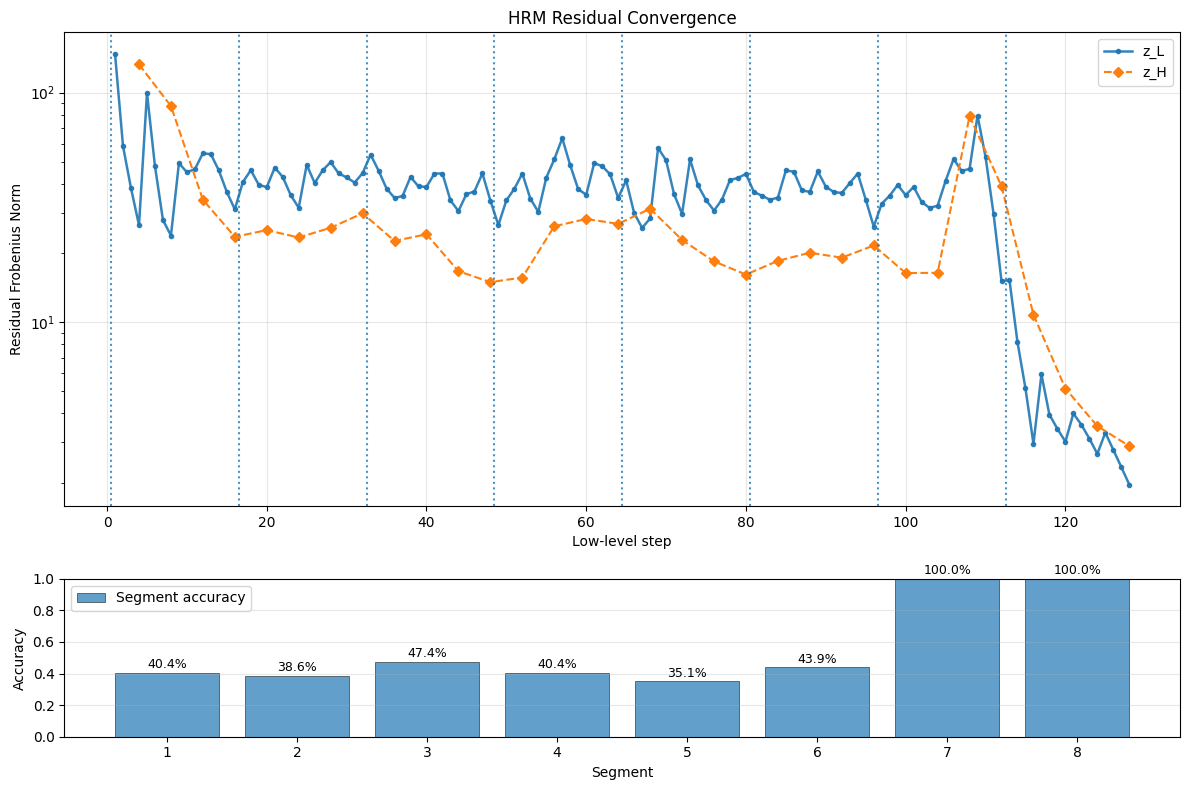

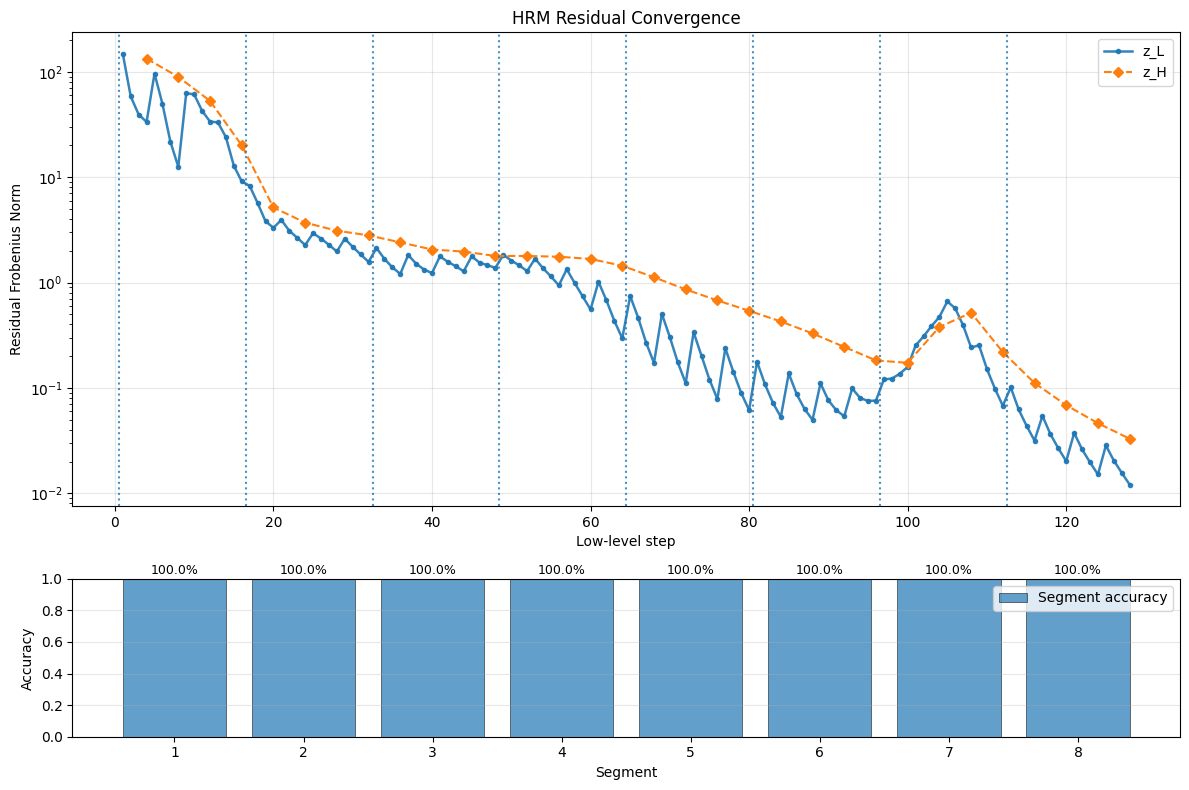

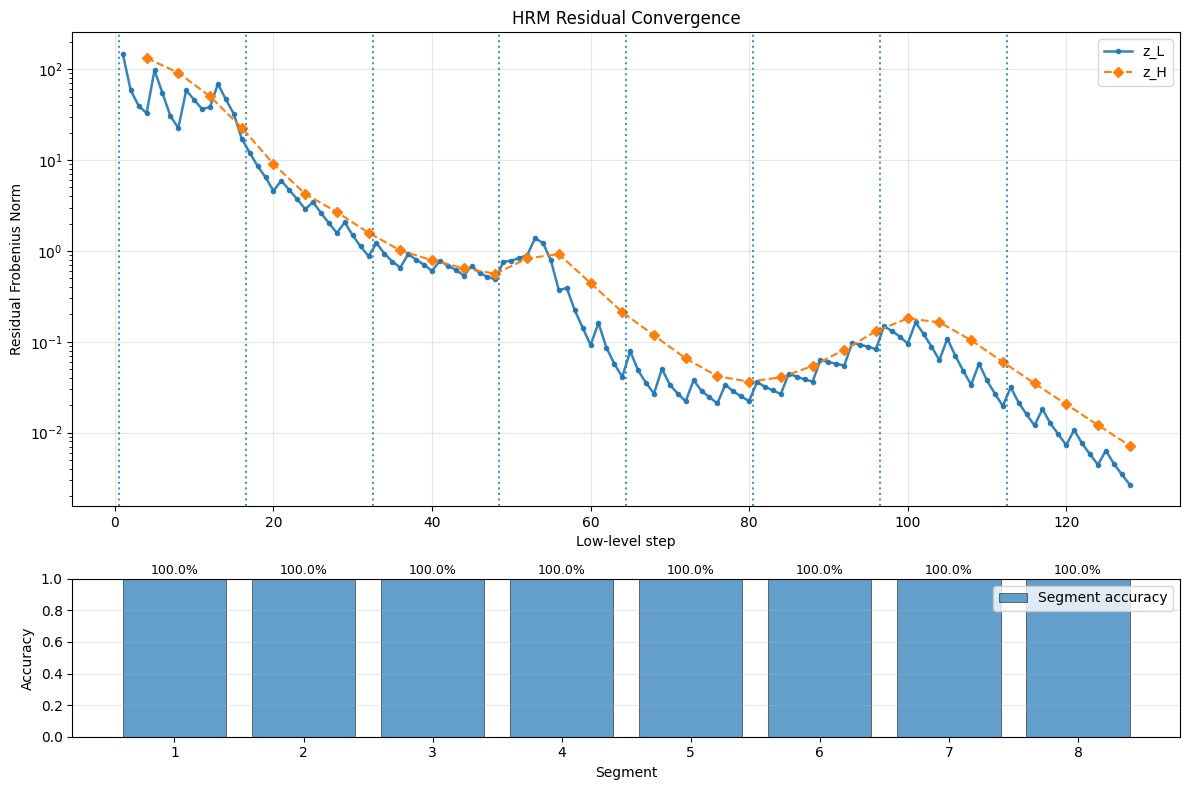

{'zL_residuals': [147.96798706054688,
  58.63788604736328,
  39.64774703979492,
  32.93144607543945,
  97.73655700683594,
  54.70976638793945,
  30.65100860595703,
  22.610546112060547,
  58.61348342895508,
  46.29908752441406,
  36.3690185546875,
  38.48255920410156,
  69.23314666748047,
  46.52354431152344,
  32.3250732421875,
  17.256750106811523,
  12.076422691345215,
  8.633339881896973,
  6.467389106750488,
  4.588807106018066,
  5.9394211769104,
  4.6855149269104,
  3.7144110202789307,
  2.885866165161133,
  3.4452810287475586,
  2.6128132343292236,
  2.0235822200775146,
  1.5771000385284424,
  2.0623679161071777,
  1.480960726737976,
  1.119118571281433,
  0.8754180669784546,
  1.219382643699646,
  0.9338552951812744,
  0.7633609175682068,
  0.6551151275634766,
  0.921363353729248,
  0.8022847771644592,
  0.7036941051483154,
  0.6024552583694458,
  0.7805125117301941,
  0.6861593723297119,
  0.6191559433937073,
  0.5359810590744019,
  0.6781626343727112,
  0.5741469264030457,
 

In [5]:
from hrm_residual_analysis import plot_residuals, collect_residuals
import matplotlib

x, y = next(data_iter)
# print(x.shape)
add = 5

T= 4

HRM_model = HRM(
    L_module=low_level,
    H_module=high_level,
    encoder=encoder,
    head=head,
    M=M,
    N=N,
    T=T,
    max_len=81,
    d_model=d_model,
).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in HRM_model.parameters() if p.requires_grad):,}",
)

HRM_model, _, _, _, _ = load_checkpoint(
    HRM_model,
    optimizer=None,
    scheduler=None,
    path="checkpoints/hrm_best_34M.pt",
    device=device,
)
HRM_model.eval()
plot_residuals(HRM_model, x[0], y[0], log_scale=True, device=device)
plot_residuals(HRM_model, x[1], y[1], log_scale=True, device=device)
plot_residuals(HRM_model, x[2], y[2], log_scale=True, device=device)
plot_residuals(HRM_model, x[3], y[3], log_scale=True, device=device)
plot_residuals(HRM_model, x[4], y[4], log_scale=True, device=device)

